<a href="https://colab.research.google.com/github/balasri03/Mini_project/blob/main/covid19_bert_bert_bart_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

dharanimanchala_covid_19_path = kagglehub.dataset_download('dharanimanchala/covid-19')

print('Data source import complete.')


In [ ]:
!pip install transformers -q

In [ ]:
import torch
import time
import numpy as np
import pandas as pd

from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
train_df = pd.read_csv("/kaggle/input/datasets/dharanimanchala/covid-19/C19_train (1).csv")
val_df = pd.read_csv("/kaggle/input/datasets/dharanimanchala/covid-19/C19_val (1).csv")
test_df=pd.read_csv("/kaggle/input/datasets/dharanimanchala/covid-19/C19_test (1).csv")

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)          # remove URLs
    text = re.sub(r"@\w+", "", text)                    # remove mentions
    text = re.sub(r"#", "", text)                       # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)                # keep only letters
    text = re.sub(r"\s+", " ", text).strip()            # remove extra spaces
    return text

In [ ]:
train_df["clean_text"] = train_df["Tweet"].apply(clean_text)
val_df["clean_text"] = val_df["Tweet"].apply(clean_text)
test_df["clean_text"] = test_df["Tweet"].apply(clean_text)

In [ ]:
train_df.head()

,Tweet,Target 1,Stance 1,Opinion Towards,Sentiment,Tweet Id,clean_text
0,@SuzanneEvans1 @Jo_Turandot @LadyTrumpington S...,face masks,FAVOR,1. The tweet explicitly expresses opinion abo...,pos,1.280000e+18,surgeons amp nurses wear them for hours every ...
1,I try to be unbiased on my Twitter.\n\nWhich i...,face masks,FAVOR,1. The tweet explicitly expresses opinion abo...,pos,1.280000e+18,i try to be unbiased on my twitter which is wh...
2,@GOPLeader So 9 out of 10 members of Congress ...,face masks,FAVOR,2. The tweet does NOT expresses opinion about ...,neg,1.290000e+18,so out of members of congress with covid is a ...
3,@AvantiWestCoast I’m in coach F en route to Lo...,face masks,FAVOR,1. The tweet explicitly expresses opinion abo...,neg,1.280000e+18,im in coach f en route to london euston from s...
4,"When you wear a mask, wear it correctly... cov...",face masks,FAVOR,1. The tweet explicitly expresses opinion abo...,pos,1.290000e+18,when you wear a mask wear it correctly cover y...


In [ ]:
from collections import Counter

def build_vocab(texts, min_freq=5):
    counter = Counter()

    for text in texts:
        words = text.split()
        counter.update(words)

    vocab = {"<pad>":0, "<unk>":1}

    for word,freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab


In [ ]:
def text_to_seq(text, vocab):
    words = text.split()

    return [
        vocab.get(word, vocab["<unk>"])
        for word in words
    ]


In [ ]:
train_df["input_text"] = train_df["clean_text"] + " " + train_df["Target 1"].apply(clean_text)
val_df["input_text"]   = val_df["clean_text"]   + " " + val_df["Target 1"].apply(clean_text)
test_df["input_text"]  = test_df["clean_text"]  + " " + test_df["Target 1"].apply(clean_text)
vocab = build_vocab(train_df["input_text"].tolist())
print(f"Vocab size: {len(vocab)}")

Vocab size: 2256


In [ ]:
train_df["input_text"][0]

'surgeons amp nurses wear them for hours every day standing up wo breaks during surgeries cowgirl up face masks'

In [ ]:

label_col = "Stance 1"
unique_labels = sorted(train_df[label_col].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {v: k for k, v in label2id.items()}

print("Label mapping:", label2id)

Label mapping: {'AGAINST': 0, 'FAVOR': 1, 'NONE': 2}


In [ ]:
print(label2id)
print(val_df["Stance 1"].unique())
print(train_df["input_text"].head(10))

{'AGAINST': 0, 'FAVOR': 1, 'NONE': 2}
['FAVOR' 'AGAINST' 'NONE']
0    surgeons amp nurses wear them for hours every ...
1    i try to be unbiased on my twitter which is wh...
2    so out of members of congress with covid is a ...
3    im in coach f en route to london euston from s...
4    when you wear a mask wear it correctly cover y...
5    omg people say i have to wear a mask and im cr...
6    a cute girl told me she loved my mask today i ...
7    employee correct mask wearing customer mask we...
8    what a bunch of hillbillies that asshole is pr...
9    whats schantz the democrat governors of wa and...
Name: input_text, dtype: object


In [ ]:
print(train_df.columns)

Index(['Tweet', 'Target 1', 'Stance 1', 'Opinion Towards', 'Sentiment',
       'Tweet Id', 'clean_text', 'input_text'],
      dtype='object')


In [ ]:
label2id = {
    "AGAINST": 0,
    "FAVOR": 1,
    "NONE": 2
}

train_df["label"] = train_df["Stance 1"].map(label2id)
val_df["label"]   = val_df["Stance 1"].map(label2id)
test_df["label"]  = test_df["Stance 1"].map(label2id)

In [ ]:
X_train = train_df["input_text"].tolist()
y_train = train_df["label"].tolist()

X_val = val_df["input_text"].tolist()
y_val = val_df["label"].tolist()

X_test = test_df["input_text"].tolist()
y_test = test_df["label"].tolist()

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
class StanceDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_len):

        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
MAX_LEN = 128
BATCH_SIZE = 16

train_dataset = StanceDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = StanceDataset(X_val, y_val, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

model = model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
start_train = time.time()

for epoch in range(3):

    model.train()

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        optimizer.step()

end_train = time.time()

training_time = (end_train - start_train)/3600

In [ ]:
start_inf = time.time()

model.eval()

preds = []
true_labels = []

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        preds.extend(torch.argmax(logits, axis=1).cpu().numpy())
        true_labels.extend(batch["labels"].numpy())

end_inf = time.time()

inference_time = end_inf - start_inf



In [ ]:
accuracy = accuracy_score(true_labels, preds)
precision = precision_score(true_labels, preds, average="macro")
recall = recall_score(true_labels, preds, average="macro")
f1 = f1_score(true_labels, preds, average="macro")

print("Training Time:", training_time)
print("Inference Time:", inference_time)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Training Time: 0.08209345678488414
Inference Time: 6.14334511756897
Accuracy: 0.68
Precision: 0.6775264159929765
Recall: 0.677066498570512
F1 Score: 0.6768418103142513


Confusion Matrix:
 [[149  60  34]
 [ 27 205  31]
 [ 25  31 238]]


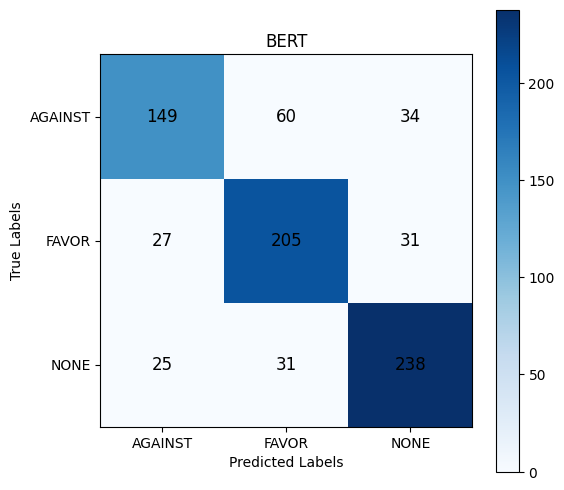

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix

# # Compute confusion matrix
# cm = confusion_matrix(true_labels, preds)

# # Print raw confusion matrix
# print("Confusion Matrix:\n", cm)

# # Class labels (make sure order matches label encoding)
# labels = ["AGAINST", "FAVOR", "NONE"]

# # Plot heatmap
# plt.figure(figsize=(6,5))
# sns.heatmap(cm,
#             annot=True,
#             fmt="d",
#             cmap="Blues",
#             xticklabels=labels,
#             yticklabels=labels)

# plt.xlabel("Predicted Labels")
# plt.ylabel("True Labels")
# plt.title("BERT")

# plt.show()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Step 1: Compute confusion matrix
cm = confusion_matrix(true_labels, preds)

# Print raw confusion matrix
print("Confusion Matrix:\n", cm)

# Step 2: Class labels
labels = ["AGAINST", "FAVOR", "NONE"]

# Step 3: Create diagonal-only matrix
diag_matrix = np.zeros_like(cm)

for i in range(len(cm)):
    diag_matrix[i, i] = cm[i, i]

# Step 4: Plot
plt.figure(figsize=(6,6))

# Only diagonal will be colored
plt.imshow(diag_matrix, cmap='Blues', vmin=0, vmax=np.max(cm))

# Step 5: Add all values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha='center',
            va='center',
            color='black',
            fontsize=12
        )

# Step 6: Axis labels
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("BERT")

plt.grid(False)
plt.colorbar()

plt.show()

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print("Total Parameters:", total_params)

Total Parameters: 109484547


In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable Parameters:", trainable_params)

Trainable Parameters: 109484547


In [ ]:
params_million = total_params / 1e6
print("Parameters (Million):", round(params_million, 3), "M")

Parameters (Million): 109.485 M


In [ ]:
!pip install transformers -q

In [ ]:
from transformers import BartTokenizer, BartForSequenceClassification

In [ ]:
tokenizer = BartTokenizer.from_pretrained("facebook/bart-base")

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
class StanceDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
MAX_LEN = 128
BATCH_SIZE = 16

train_dataset = StanceDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = StanceDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset  = StanceDataset(X_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [ ]:
model = BartForSequenceClassification.from_pretrained(
    "facebook/bart-base",
    num_labels=3
)

model = model.to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

BartForSequenceClassification LOAD REPORT from: facebook/bart-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.dense.bias      | MISSING | 
classification_head.out_proj.bias   | MISSING | 
classification_head.dense.weight    | MISSING | 
classification_head.out_proj.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
start_train = time.time()

for epoch in range(3):

    model.train()

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        optimizer.step()

end_train = time.time()

training_time = (end_train - start_train)/3600

In [ ]:
start_inf = time.time()

model.eval()

preds = []
true_labels = []
probs = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)

        preds.extend(torch.argmax(probabilities, axis=1).cpu().numpy())
        probs.extend(probabilities.cpu().numpy())
        true_labels.extend(batch["labels"].numpy())

end_inf = time.time()

inference_time = end_inf - start_inf

In [ ]:
accuracy = accuracy_score(true_labels, preds)
precision = precision_score(true_labels, preds, average="macro")
recall = recall_score(true_labels, preds, average="macro")
f1 = f1_score(true_labels, preds, average="macro")

print("Training Time:", training_time)
print("Inference Time:", inference_time)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Training Time: 0.10117231051127117
Inference Time: 7.177099704742432
Accuracy: 0.74
Precision: 0.7397798825868871
Recall: 0.7340534048040034
F1 Score: 0.7339812326957356


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print("Total Parameters:", total_params)

Total Parameters: 140013315


In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable Parameters:", trainable_params)

Trainable Parameters: 140013315


In [ ]:
params_million = total_params / 1e6
print("Parameters (Million):", round(params_million, 3), "M")

Parameters (Million): 140.013 M


Confusion Matrix:
 [[149  60  34]
 [ 27 205  31]
 [ 25  31 238]]


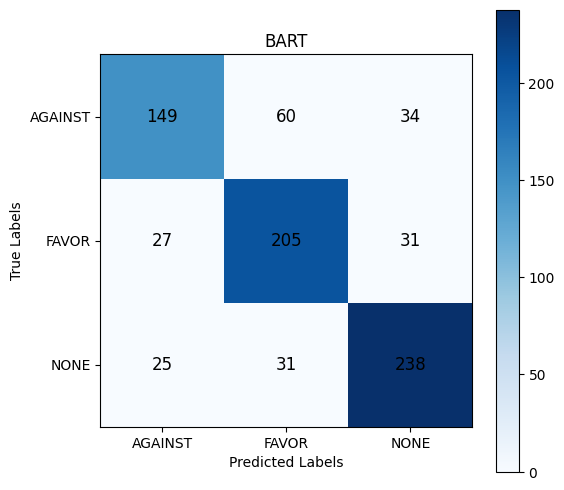

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix

# # Compute confusion matrix
# cm = confusion_matrix(true_labels, preds)

# # Print raw confusion matrix
# print("Confusion Matrix:\n", cm)

# # Class labels (make sure order matches label encoding)
# labels = ["AGAINST", "FAVOR", "NONE"]

# # Plot heatmap
# plt.figure(figsize=(6,5))
# sns.heatmap(cm,
#             annot=True,
#             fmt="d",
#             cmap="Blues",
#             xticklabels=labels,
#             yticklabels=labels)

# plt.xlabel("Predicted Labels")
# plt.ylabel("True Labels")
# plt.title("BART")

# plt.show()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Step 1: Compute confusion matrix
cm = confusion_matrix(true_labels, preds)

# Print raw confusion matrix
print("Confusion Matrix:\n", cm)

# Step 2: Class labels
labels = ["AGAINST", "FAVOR", "NONE"]

# Step 3: Create diagonal-only matrix
diag_matrix = np.zeros_like(cm)

for i in range(len(cm)):
    diag_matrix[i, i] = cm[i, i]

# Step 4: Plot
plt.figure(figsize=(6,6))

# Only diagonal cells will be colored
plt.imshow(diag_matrix, cmap='Blues', vmin=0, vmax=np.max(cm))

# Step 5: Add all values (including misclassifications)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha='center',
            va='center',
            color='black',
            fontsize=12
        )

# Step 6: Axis labels
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("BART")

plt.grid(False)
plt.colorbar()

plt.show()